<a href="https://colab.research.google.com/github/luiska147/Agente-RAG-Santo-Pegasus/blob/main/AgenteRAGSantoPegasus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-google-genai google-generativeai

In [2]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    google_api_key=GEMINI_API_KEY
)

In [4]:
PROMPT_TRIAJE = """
	Eres un especialista en triaje del Service Desk para políticas internas.
	Dado el mensaje del usuario, devuelve SÓLO un JSON con:\n
	{\n
	 "decision": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_TICKET",\n
	 "urgencia": "BAJA" | "MEDIANA" | "ALTA",\n
	 "campos_faltantes": ["..."]\n
	}\n
	Reglas:\n
	- **AUTO_RESOLVER**: Preguntas claras sobre las reglas o procedimientos descritos en las políticas (Ej.: "¿Puedo reembolsar el internet para mi oficina en casa?", "¿Cómo funciona la política de alimentación mientras viajo?").\n
	- **PEDIR_INFO**: Mensajes imprecisos o sin información para identificar el tema o el contexto (Ej.: "Necesito ayuda con una política", "Tengo una pregunta general").\n
	- **ABRIR_TICKET**: Solicitudes de excepciones, autorización, aprobación o acceso especial, o cuando el usuario solicita explícitamente abrir un ticket (Ej.: "Quiero una excepción para trabajar remotamente durante 5 días", "Solicito autorización para archivos adjuntos externos", "Por favor, abra un ticket con RR. HH.").\n
	Analiza el mensaje y decide la acción más adecuada.
"""

In [5]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field

class TriajeOut(BaseModel):
  decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_TICKET"]
  urgencia: Literal["BAJA", "MEDIANA", "ALTA"]
  campos_faltantes: List[str] = Field(default_factory=list)

In [6]:
from langchain_core.messages import SystemMessage, HumanMessage

chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
  salida: TriajeOut = chain_de_triaje.invoke(
      [
          SystemMessage(content=PROMPT_TRIAJE),
          HumanMessage(content=mensaje)
      ]
  )
  return salida.model_dump()

In [7]:
!pip install langchain_community faiss-cpu langchain-text-splitters pymupdf

In [25]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for documento in Path("/content/sample_data/archivos").glob("*.pdf"):
    try:
        loader = PyMuPDFLoader(str(documento))
        docs.extend(loader.load())
        print(f"Archivo cargado: {documento.name}")
    except Exception as e:
        print(f"Error cargando archivo: {documento.name}: {e}")

print(f"Total de documentos cargados: {len(docs)}")

Archivo cargado: 4a531743-36de-4b0b-b532-b5447b2c1ba7.pdf
Archivo cargado: 1b414aa2-c5ca-40d4-8e9c-8d9e4dcdc955.pdf
Archivo cargado: ddb400f4-475a-4ddc-9ef3-a0cbb2789447.pdf
Archivo cargado: a4266faf-77bf-4932-99b3-72e452051be2.pdf
Archivo cargado: 359dda5d-7daa-4aa1-832e-fb2843fcf70d.pdf
Total de documentos cargados: 152


In [17]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

prompt_rag = ChatPromptTemplate(
    [
        ("system",
         """
        Eres el especialista en RR.HH. de la empresa Carraro Desarrollo de Software.
        Responde siempre utilizando los conocimientos del contexto que te fue pasado.
        Si no hay información sobre la pregunta en el contexto, responde sólo 'No lo sé'.
        """),
        ("human", "Contexto: {context}.\nPregunta del empleado: {input}")
    ]
)

document_chain = create_stuff_documents_chain(llm, prompt_rag)

In [33]:
from typing import Dict

def busqueda_de_respuestas_RAG(pregunta: str) -> Dict:
    # 1. En lugar de buscar chunks por similitud,
    # le pasamos todos los documentos/páginas completos (docs)
    documentos_relacionados = docs

    if not documentos_relacionados:
        return {
            "respuesta": "No lo sé.",
            "citaciones": [],
            "documentos_encontrados": False
        }

    # 2. Invocamos directamente el document_chain pasándole 'docs'
    answer = document_chain.invoke({
        "input": pregunta,
        "context": documentos_relacionados
    })

    # Si el LLM responde que no sabe
    if answer.rstrip(".!?").strip() == 'No lo sé':
        return {
            "respuesta": "No lo sé.",
            "citaciones": [],
            "documentos_encontrados": False
        }

    return {
        "respuesta": answer,
        "citaciones": documentos_relacionados,
        "documentos_encontrados": True
    }

In [37]:
!pip install -q langgraph

In [38]:
from typing import TypedDict, Optional

class AgentState(TypedDict, total = False):
  pregunta: str
  triaje: dict
  respuesta: Optional[str]
  citaciones: Optional[list]
  rag_exito: bool
  accion_final: str

In [39]:
def nodo_triaje(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'triaje'...")
  return {"triaje": triaje(state["pregunta"])}

In [40]:
def nodo_auto_resolver(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'auto_resolver'...")
  respuesta_RAG = busqueda_de_respuestas_RAG(state["pregunta"])

  update: AgentState = {
      "respuesta": respuesta_RAG["respuesta"],
      "citaciones": respuesta_RAG["citaciones"],
      "rag_exito": respuesta_RAG["documentos_encontrados"]
  }

  if respuesta_RAG["documentos_encontrados"]:
    update["accion_final"] = "AUTO_RESOLVER"

  return update

In [41]:
def nodo_pedir_info(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'pedir_info'...")
  return {
      "respuesta": "Necesito más informaciones sobre tu pedido.",
      "citaciones": [],
      "accion_final": "PEDIR_INFO"
  }

In [42]:
def nodo_abrir_ticket(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'abrir_ticket'...")

  tri = state["triaje"]

  return {
      "respuesta": f"Abrir ticket con urgencia {tri['urgencia']}. Pedido: {state['pregunta']}.",
      "citaciones": [],
      "accion_final": "ABRIR_TICKET"
  }

In [43]:
def arista_decision_triaje(state: AgentState) -> str:
  print("Decidiendo el flujo después del nodo 'triaje'...")
  tri = state["triaje"]

  if tri["decision"] == "AUTO_RESOLVER":
    return "rag"
  elif tri["decision"] == "PEDIR_INFO":
    return "info"
  else:
    return "ticket"

In [44]:
def arista_decision_rag(state: AgentState) -> str:
  print("Decidiendo el flujo después del nodo 'auto_resolver'...")

  if state["rag_exito"]:
    print("RAG con éxito, finalizando el flujo.")
    return "ok"

  KEYWORDS_ABRIR_TICKET = ["aprobación", "aprobar", "excepción", "liberación", "autorización",
                         "autorizar", "abrir ticket", "acceso especial"]

  if any(keyword in state["pregunta"].lower() for keyword in KEYWORDS_ABRIR_TICKET):
    print("RAG ha fallado, pero hay palabras relacionadas con abrir ticket.")
    return "ticket"

  print("RAG ha fallado, pediré más informaciones al usuario.")
  return "info"

In [45]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(AgentState)

workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

workflow.add_edge(START, "triaje")
workflow.add_conditional_edges("triaje", arista_decision_triaje, {
    "rag": "auto_resolver",
    "info": "pedir_info",
    "ticket": "abrir_ticket"
})

workflow.add_conditional_edges("auto_resolver", arista_decision_rag, {
    "info": "pedir_info",
    "ticket": "abrir_ticket",
    "ok": END
})

workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_ticket", END)

grafo = workflow.compile()

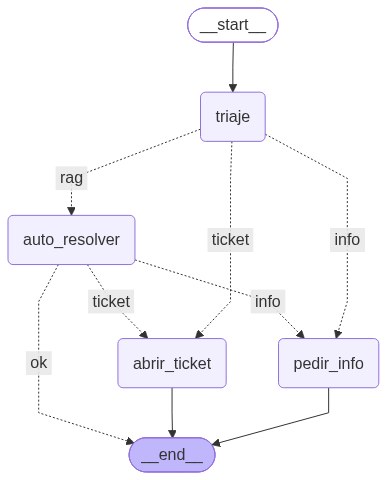

In [46]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [51]:
PREGUNTA = "Cual es la guia de Configuración del Entorno Local — Front-end "

respuesta = grafo.invoke({"pregunta": PREGUNTA})
print("")
print(f"PREGUNTA: {PREGUNTA}")
print(f"DECISIÓN DE TRIAJE: {respuesta['triaje']['decision']} | URGENCIA: {respuesta['triaje']['urgencia']} | ACCIÓN FINAL: {respuesta['accion_final']}")
print(f"RESPUESTA: {respuesta['respuesta']}")


Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con éxito, finalizando el flujo.

PREGUNTA: Cual es la guia de Configuración del Entorno Local — Front-end 
DECISIÓN DE TRIAJE: AUTO_RESOLVER | URGENCIA: BAJA | ACCIÓN FINAL: AUTO_RESOLVER
RESPUESTA: La guía de **Configuración del Entorno Local — Front-end** se encuentra detallada en la **Sección 5** del *Manual de Onboarding para Nuevos Desarrolladores*. Los puntos clave son:

*   **Requisitos Previos:** Sistema operativo (macOS 13+, Ubuntu 22.04+ o Windows 11 con WSL2), al menos 8 GB de RAM, 20 GB de espacio libre y conexión a la VPN corporativa.
*   **Gestión de Versiones (Node.js):** Se debe utilizar **NVM** (Node Version Manager) para instalar y gestionar la versión **Node.js 20+**.
*   **Editor de Código:** Se utiliza **Visual Studio Code** con extensiones obligatorias (ESLint, Prettier, GitLens, TypeScript Her